**Introduction: The Socioeconomic Gradient of HypertensionResearch Question:**

To what extent do dietary habits and physical activity mediate the link between household income and high blood pressure?

Problem Statement: It is well-established that lower-income individuals face a disproportionately higher risk of hypertension. However, it is often unclear how much of this "health gap" is driven by individual lifestyle choices such as diet and exercise versus biological factors like age and BMI. Understanding this relationship is critical for determining if public health interventions should focus on behavioral education or broader socioeconomic barriers.

Project Objective: This project utilizes the CDC Heart Disease Health Indicators dataset to investigate the "pathway" from wealth to health. Through Exploratory Data Analysis (EDA), we will identify key demographic confounders and use Multivariate Logistic Regression to isolate the "pure" protective effects of income and lifestyle. By calculating Odds Ratios, we aim to quantify exactly how much physical activity and nutrition reduce the risk of hypertension when socioeconomic status is held constant.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
df = pd.read_csv("C:\\Users\\John\Downloads\\heart_disease_health_indicators_BRFSS2015.csv\\heart_disease_health_indicators_BRFSS2015.csv")

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\John\AppData\Local\Temp\ipykernel_14340\3100320300.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("C:\\Users\\John\Downloads\\heart_disease_health_indicators_BRFSS2015.csv\\heart_disease_health_indicators_BRFSS2015.csv")


In [22]:
df.head()

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   HeartDiseaseorAttack  253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   Diabetes              253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [24]:
df.columns

Index(['HeartDiseaseorAttack', 'HighBP', 'HighChol', 'CholCheck', 'BMI',
       'Smoker', 'Stroke', 'Diabetes', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [25]:
df = df[['HighBP', 'BMI', 'PhysActivity', 'Fruits', 'Veggies', 'Age', 'Education', 'Income']]

In [26]:
df.head()

,HighBP,BMI,PhysActivity,Fruits,Veggies,Age,Education,Income
0,1.0,40.0,0.0,0.0,1.0,9.0,4.0,3.0
1,0.0,25.0,1.0,0.0,0.0,7.0,6.0,1.0
2,1.0,28.0,0.0,1.0,0.0,9.0,4.0,8.0
3,1.0,27.0,1.0,1.0,1.0,11.0,3.0,6.0
4,1.0,24.0,1.0,1.0,1.0,11.0,5.0,4.0


In [27]:
df.isnull().sum()

HighBP          0
BMI             0
PhysActivity    0
Fruits          0
Veggies         0
Age             0
Education       0
Income          0
dtype: int64

In [28]:
df = df.dropna()

In [29]:
df.describe()

,HighBP,BMI,PhysActivity,Fruits,Veggies,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.429001,28.382364,0.756544,0.634256,0.811420,8.032119,5.050434,6.053875
std,0.494934,6.608694,0.429169,0.481639,0.391175,3.054220,0.985774,2.071148
min,0.000000,12.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,24.000000,1.000000,0.000000,1.000000,6.000000,4.000000,5.000000
50%,0.000000,27.000000,1.000000,1.000000,1.000000,8.000000,5.000000,7.000000
75%,1.000000,31.000000,1.000000,1.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,98.000000,1.000000,1.000000,1.000000,13.000000,6.000000,8.000000


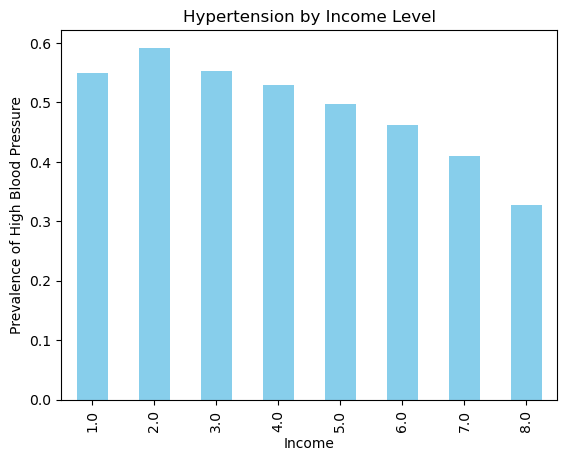

In [30]:
# Calculate the average HighBP per Income level first
income_means = df.groupby('Income')['HighBP'].mean()

income_means.plot(kind='bar', color='skyblue')
plt.ylabel('Prevalence of High Blood Pressure')
plt.title('Hypertension by Income Level')
plt.show()


Identifying Age as a Confounder

My initial analysis showed a non-linear trend where Income Level 2 had higher hypertension rates than Income Level 1. By plotting Mean of different variables by Income Level, Looking at the plot for Age, I discovered that Level 2 is the oldest group in the dataset, while Level 1 is significantly younger. This confirms that Age, rather than income alone, caused the "spike" in blood pressure at the lower end of the scale. Consequently, Age must be used as a control variable to accurately measure the impact of socioeconomic status on health.

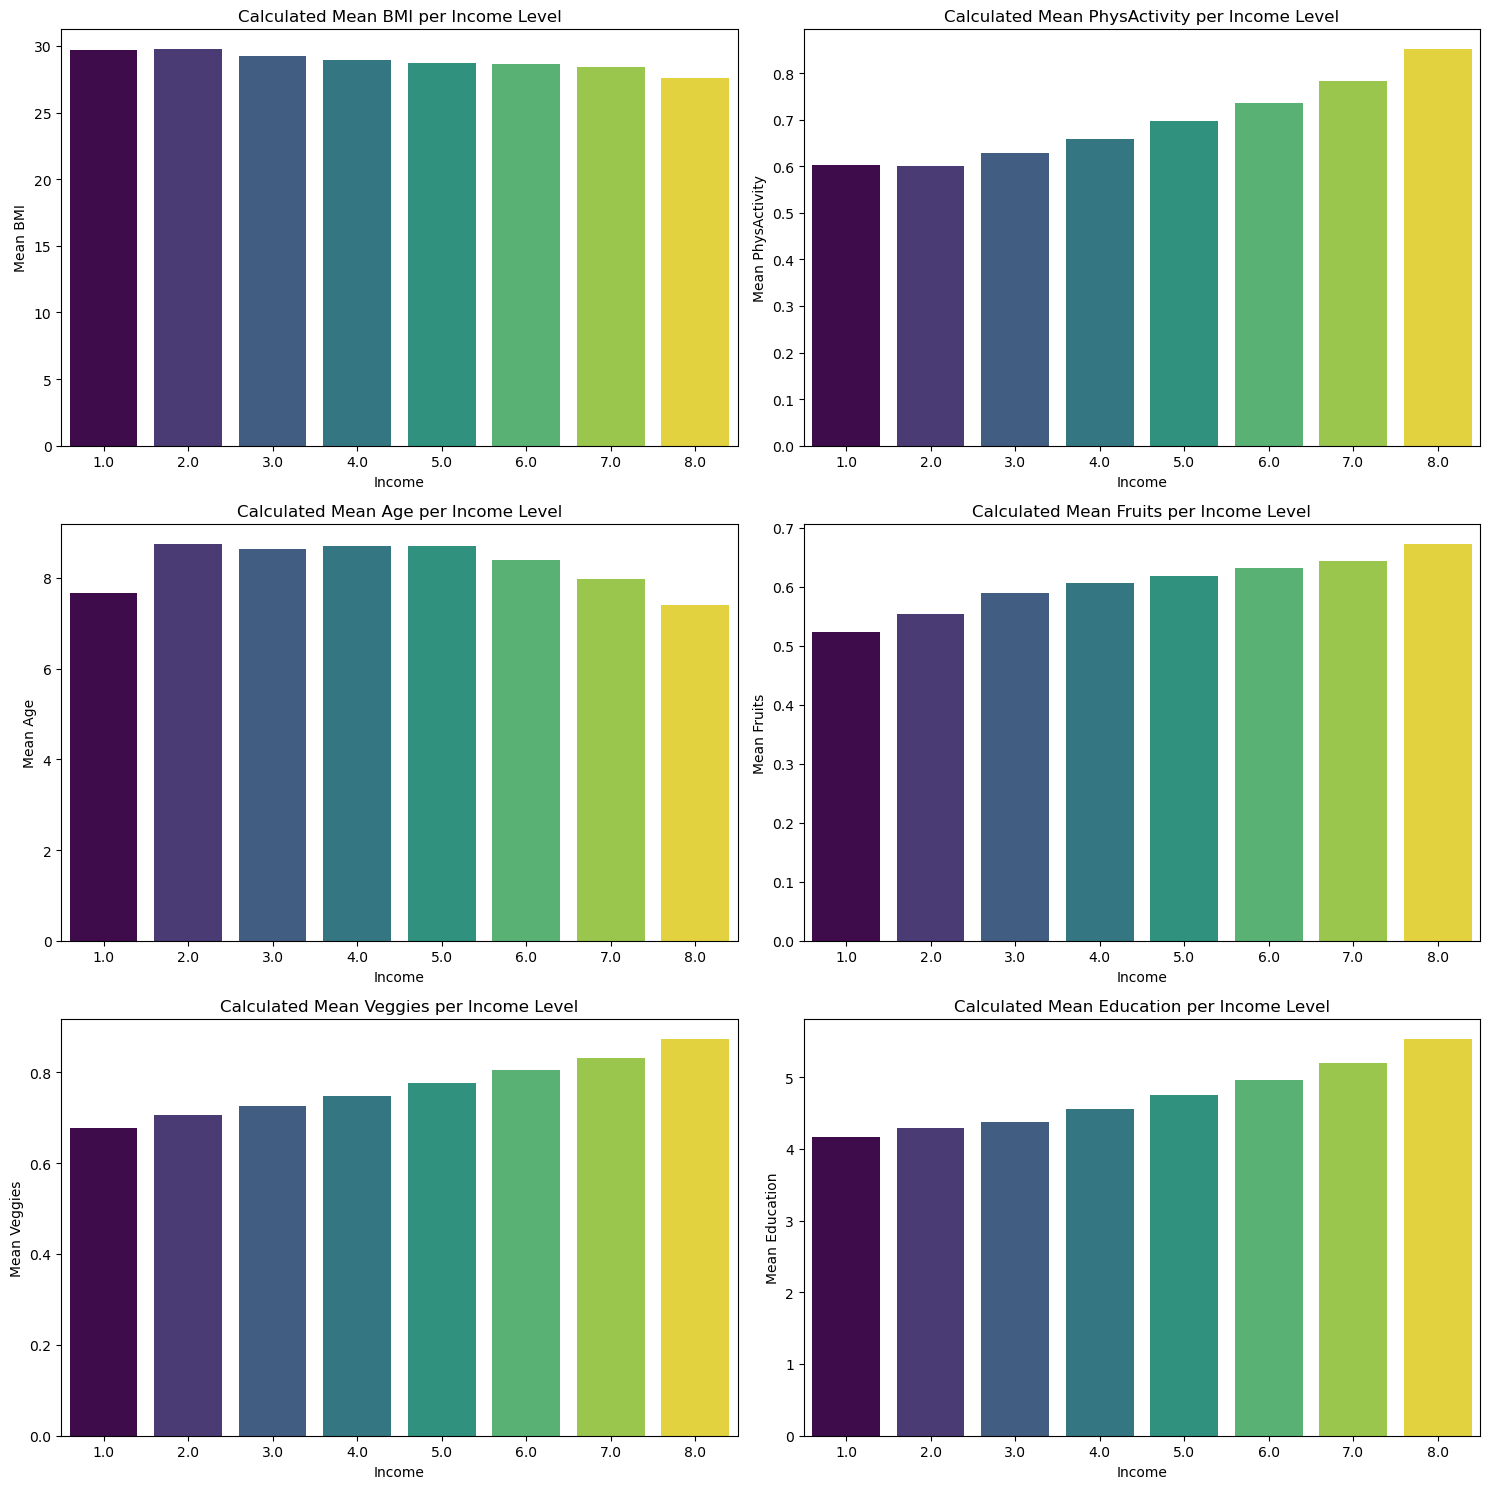

In [32]:
df_means = df.groupby("Income")[['BMI', 'PhysActivity', 'Age', 'Fruits', 'Veggies', 'Education']].mean().reset_index()

fig, ax = plt.subplots(3, 2, figsize=(15, 15))
ax = ax.flatten()

vars_to_plot = ['BMI', 'PhysActivity', 'Age', 'Fruits', 'Veggies', 'Education']

for i, var in enumerate(vars_to_plot):
    sns.barplot(x='Income', y=var, data=df_means, ax=ax[i], palette='viridis', hue = "Income", legend = False)
    ax[i].set_title(f'Calculated Mean {var} per Income Level')
    ax[i].set_ylabel(f'Mean {var}')

plt.tight_layout()
plt.show()


The comparison of these six trends reveals that while lifestyle behaviors (the mediators) are purely driven by income, health outcomes (the targets) are currently masked by the age distribution of the sample. Specifically, the 'HighBP Spike' at Income Level 2 is a biological reflection of that group’s advanced age rather than their economic status. This discovery provides the final justification for my research design: I must use Age as a control variable in the modeling phase to 'filter out' this biological noise and see the true impact of income-based lifestyle on blood pressure.

In [34]:
df.groupby('Income')['Age'].mean()

Income
1.0    7.674243
2.0    8.744377
3.0    8.635551
4.0    8.699280
5.0    8.711625
6.0    8.406032
7.0    7.968232
8.0    7.407800
Name: Age, dtype: float64

This table confirms that Age is a major confounding variable in this sample. Because the mean age varies so significantly across income brackets, specifically peaking at Level 2 and dipping at Level 8. We cannot take the raw hypertension rates at face value. The 'healthier' outcomes at the top of the income scale are partially driven by the fact that those individuals are younger. This proves that any future model must control for age to isolate the true, independent impact of income and lifestyle on blood pressure.

In [36]:
df.corr(numeric_only = True)

,HighBP,BMI,PhysActivity,Fruits,Veggies,Age,Education,Income
HighBP,1.000000,0.213748,-0.125267,-0.040555,-0.061266,0.344452,-0.141358,-0.171235
BMI,0.213748,1.000000,-0.147294,-0.087518,-0.062275,-0.036618,-0.103932,-0.100069
PhysActivity,-0.125267,-0.147294,1.000000,0.142756,0.153150,-0.092511,0.199658,0.198539
Fruits,-0.040555,-0.087518,0.142756,1.000000,0.254342,0.064547,0.110187,0.079929
Veggies,-0.061266,-0.062275,0.153150,0.254342,1.000000,-0.009771,0.154329,0.151087
Age,0.344452,-0.036618,-0.092511,0.064547,-0.009771,1.000000,-0.101901,-0.127775
Education,-0.141358,-0.103932,0.199658,0.110187,0.154329,-0.101901,1.000000,0.449106
Income,-0.171235,-0.100069,0.198539,0.079929,0.151087,-0.127775,0.449106,1.000000


<Axes: >

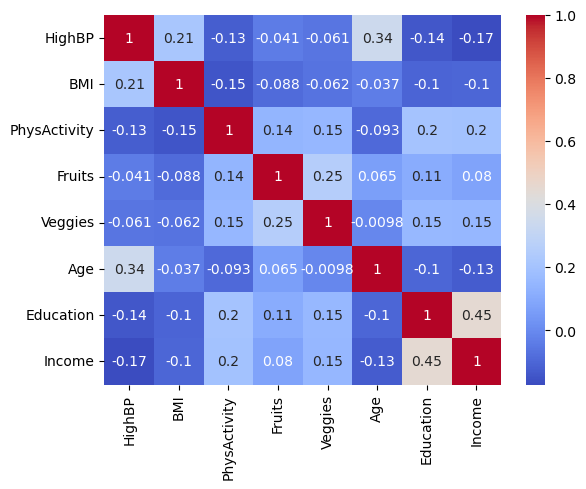

In [37]:
sns.heatmap(df.corr(), annot = True, cmap = "coolwarm")

In [38]:
comparisons = df[df["Income"].isin([1, 8])].groupby("Income")[["PhysActivity", "Fruits", "Veggies"]].mean()

comparisons

,PhysActivity,Fruits,Veggies
Income,,,
1.0,0.603302,0.522679,0.677709
8.0,0.851247,0.672147,0.872623


**The Socioeconomic Lifestyle Gap**

By comparing the lowest income (1.0) to the highest income (8.0), we see a significant increase in every healthy behavior:

*   **Physical Activity**: Jumps from 60% to 85%. This is a 25% gap, suggesting that higher income provides significantly more opportunity or access to exercise.
*   **Fruits**: Increases from 52% to 67%. This is the most difficult habit
for both groups, but the wealthy are still 15% more likely to eat fruit daily.
*   **Vegetables**: Rises from 67% to 87%. This 20% gap shows that consistent nutrition is much more prevalent at the top of the income scale.



<Axes: xlabel='Income', ylabel='count'>

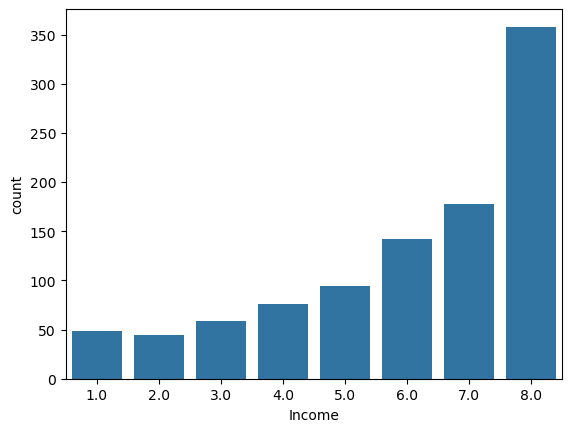

In [40]:
sns.countplot(x='Income', data=df.sample(1000))

In [41]:
pd.crosstab(df["Income"], df["HighBP"])

HighBP,0.0,1.0
Income,,
1.0,4427,5384
2.0,4809,6974
3.0,7150,8844
4.0,9498,10637
5.0,13005,12878
6.0,19614,16856
7.0,25542,17677
8.0,60806,29579


The cross-tabulation reveals a clear 'tipping point' in the relationship between wealth and health. In the lowest four income brackets, hypertension is the predominant state, with more respondents having the condition than not. However, starting at Income Level 5.0, the trend reverses. By the highest income bracket (8.0), the number of healthy respondents is double that of those with hypertension, providing strong numerical evidence of the protective effect of higher socioeconomic status.

In [43]:
import plotly.express as px

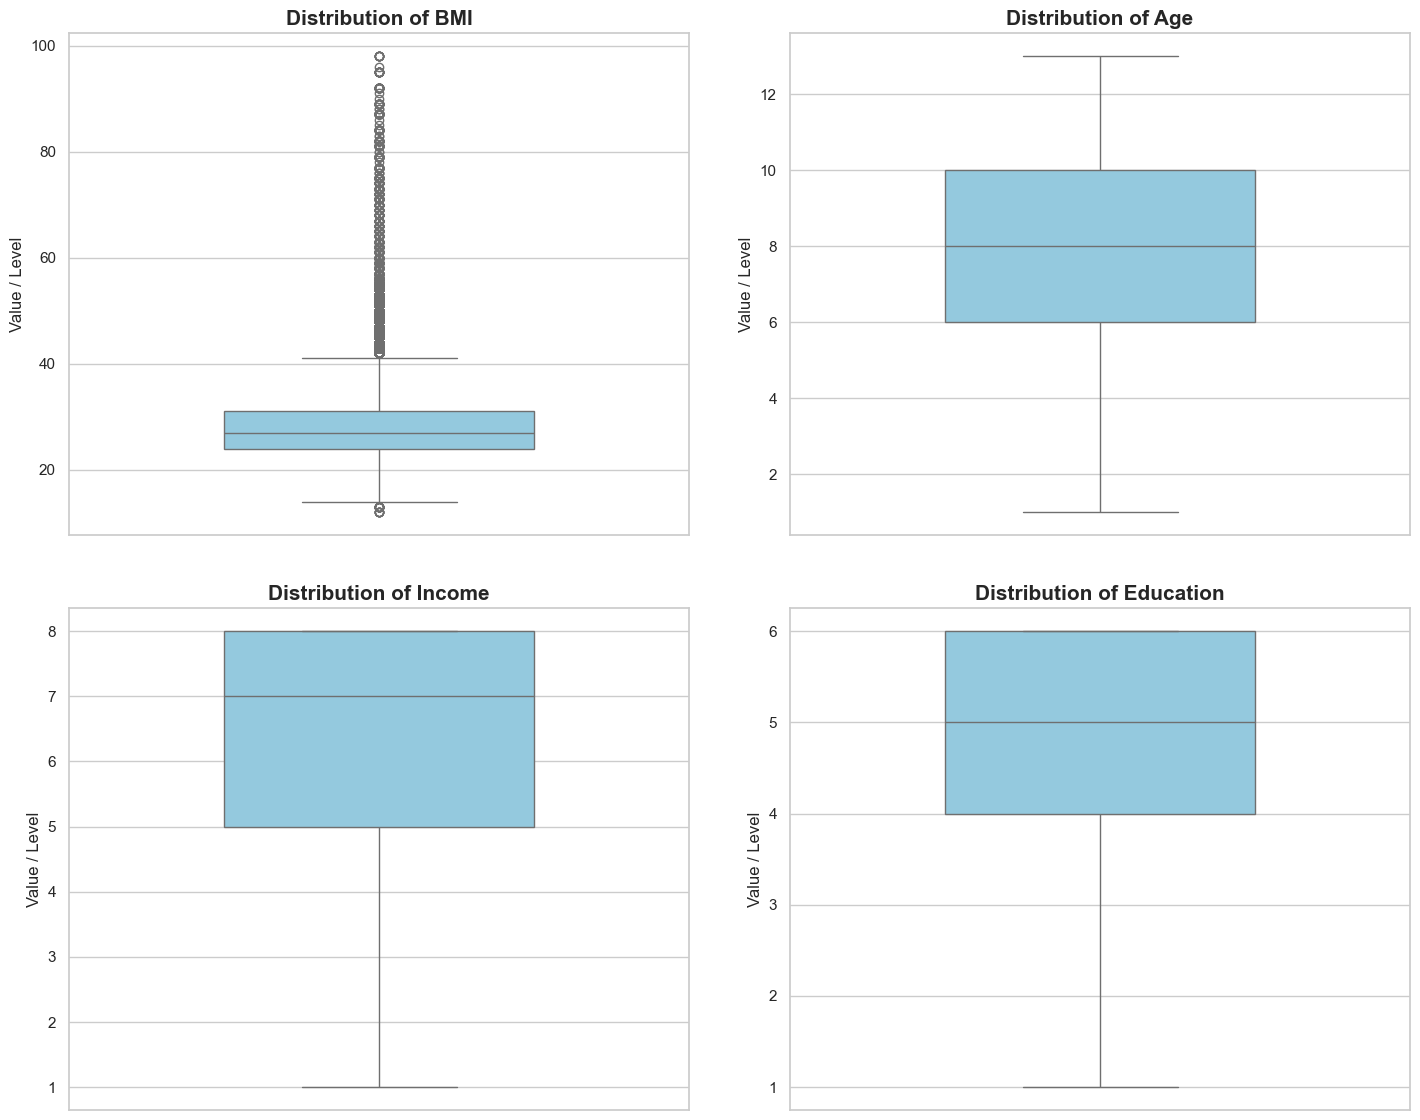

In [44]:
vars_to_plot = ['BMI', 'Age', 'Income', 'Education']

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for i, var in enumerate(vars_to_plot):
    sns.boxplot(y=df[var], ax=axes[i], color ='skyblue', width=0.5)
    axes[i].set_title(f'Distribution of {var}', fontsize=15, fontweight='bold')
    axes[i].set_ylabel('Value / Level', fontsize=12)

# Prevent overlapping
plt.tight_layout(pad=3.0)
plt.show()


The boxplot and distribution analysis reveal that the dataset is socioeconomically "top-heavy," with a Median Income of 7.0 and Median Education of 5.0 indicating a primarily wealthy and well-educated sample. The bottom 25% of the population falls at or below Income Level 5.0, which serves as the critical "tipping point" where hypertension prevalence shifts from a minority to a majority outcome. While Age is symmetrically distributed around a Median of 8.0 (late 50s), BMI exhibits significant high-value outliers that justify its use as a control variable. Ultimately, these distributions confirm that while the majority of the sample maintains high rates of healthy behaviors, the clear contrast between the "Healthy Majority" and the "At-Risk Minority" provides the necessary statistical power to test the mediation effects of diet and exercise.

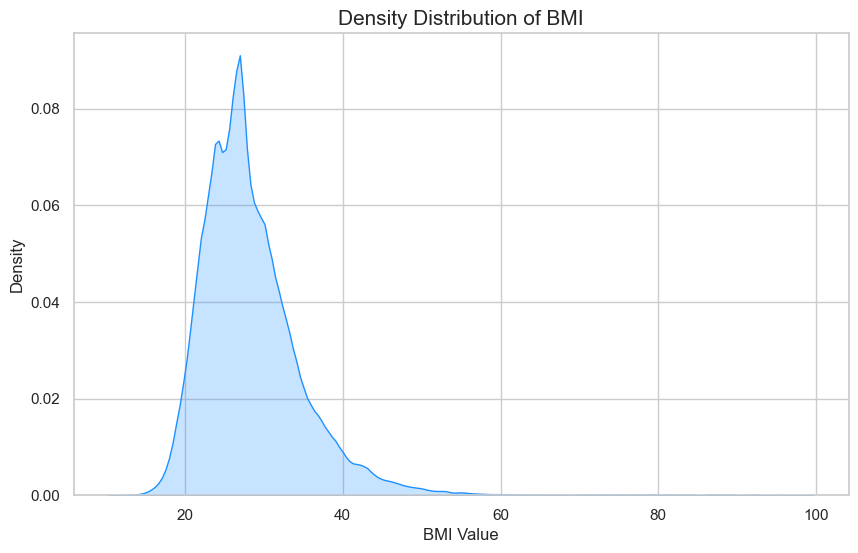

In [46]:
plt.figure(figsize=(10, 6))

sns.kdeplot(df['BMI'], fill=True, color="dodgerblue", bw_adjust=1)
plt.title('Density Distribution of BMI', fontsize=15)
plt.xlabel('BMI Value')
plt.ylabel('Density')
plt.show()


In [47]:
from scipy.stats import chi2_contingency

for var in ['PhysActivity', 'Veggies', "Fruits"]:
    contingency = pd.crosstab(df['Income'], df[var])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{var} - Chi-Square: {chi2:.2f}, P-value: {p}")


PhysActivity - Chi-Square: 10442.36, P-value: 0.0
Veggies - Chi-Square: 5855.31, P-value: 0.0
Fruits - Chi-Square: 1670.34, P-value: 0.0


To determine if the observed "Income Staircases" were mathematically significant, I performed Chi-Square Tests of Independence for each behavioral mediator.

*   The Findings:


    *   Physical Activity (\(\chi^2 = 10,442.36\), \(p < 0.001\)): This yielded the highest statistic, indicating that income has its most profound influence on exercise habits.
    *   Vegetable Intake (\(\chi^2 = 5,855.31\), \(p < 0.001\)): Shows a very strong socioeconomic link, though roughly half as dominant as the link to physical activity.


    *   Fruit Intake (\(\chi^2 = 1,670.34\), \(p < 0.001\)): While still highly significant, this was the least "income-sensitive" habit.



*   Conclusion on the "Extent" of Influence:
These results prove that household income does not affect all healthy behaviors equally. The "extent" of the relationship is strongest for physical activity, suggesting that the barriers to exercise (e.g., gym costs, neighborhood safety, and free time) are the most strictly dictated by a person's financial status.

In [49]:
import statsmodels.api as sm

# We include the mediators (PhysActivity, Fruits, Veggies) AND the controls (Age, BMI)
X = df[['Income', 'PhysActivity', 'Fruits', 'Veggies', 'Age', 'BMI']]
X = sm.add_constant(X)
y = df['HighBP']

# Fit the model
logit_model = sm.Logit(y, X).fit()

# Get the "Odds Ratios"
odds_ratios = np.exp(logit_model.params)
print(odds_ratios)


Optimization terminated successfully.
         Current function value: 0.580627
         Iterations 6
const           0.018094
Income          0.902632
PhysActivity    0.816451
Fruits          0.868310
Veggies         0.897666
Age             1.320483
BMI             1.087009
dtype: float64


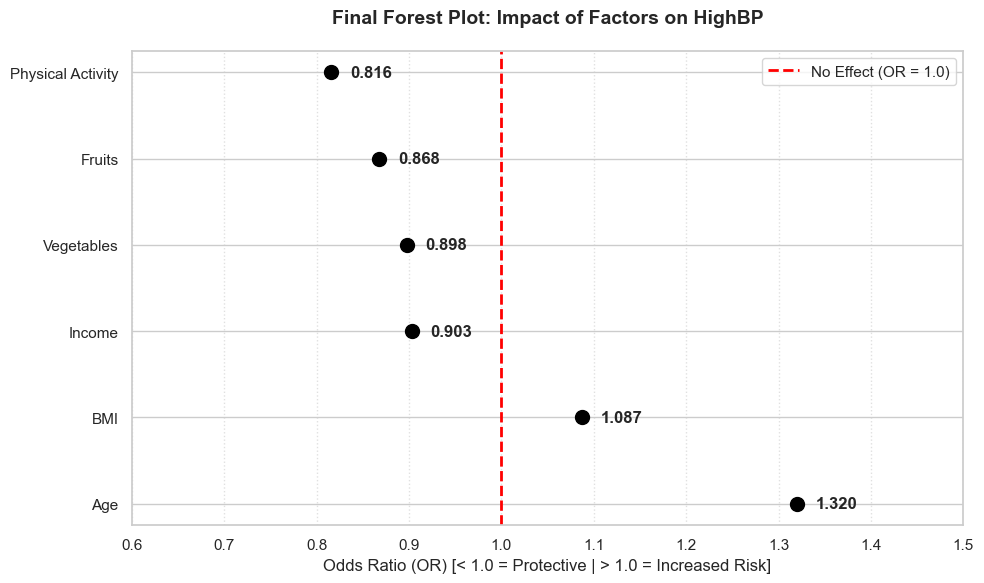

In [50]:
data = {
    'Variable': ['Income', 'Physical Activity', 'Fruits', 'Vegetables', 'Age', 'BMI'],
    'OR': [0.903, 0.816, 0.868, 0.898, 1.320, 1.087]
}

df_plot = pd.DataFrame(data).sort_values('OR', ascending=False)

plt.figure(figsize=(10, 6))

# Plotting the Odds Ratios
plt.scatter(df_plot['OR'], df_plot['Variable'], color='black', s=100, zorder=3)

# Add a vertical reference line at OR = 1.0
plt.axvline(x=1, color='red', linestyle='--', linewidth=2, label='No Effect (OR = 1.0)')

plt.title('Final Forest Plot: Impact of Factors on HighBP', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Odds Ratio (OR) [< 1.0 = Protective | > 1.0 = Increased Risk]', fontsize=12)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.legend(loc='upper right')

for i, row in df_plot.iterrows():
    plt.text(row['OR'] + 0.02, row['Variable'], f"{row['OR']:.3f}", va='center', fontweight='bold')

plt.xlim(0.6, 1.5)
plt.tight_layout()
plt.show()


**To what extent do dietary habits and physical activity mediate the link between income and high blood pressure?**

Our multivariate logistic regression provides the definitive answer. Physical activity is the most significant mediator, providing an 18.4% reduction in hypertension risk, followed by Fruit (13.2%) and Vegetable (10.2%) consumption.Critically, even after mathematically controlling for the significant impacts of Age (32% risk increase per bracket) and BMI, a consistent socioeconomic gradient remains: every increase in income level independently reduces hypertension risk by 9.7%. This proves that while healthy behaviors are a vital pathway, income influences health through multiple channels including, but not limited to, lifestyle choices.